Logistic → Acc:1.00 | Prec:1.00 | Recall:1.00
RandomForest → Acc:1.00 | Prec:1.00 | Recall:1.00
XGBoost → Acc:0.50 | Prec:0.50 | Recall:1.00

Best Model: ('Logistic', 1.0)

Best Params: {'max_depth': 3, 'n_estimators': 50}


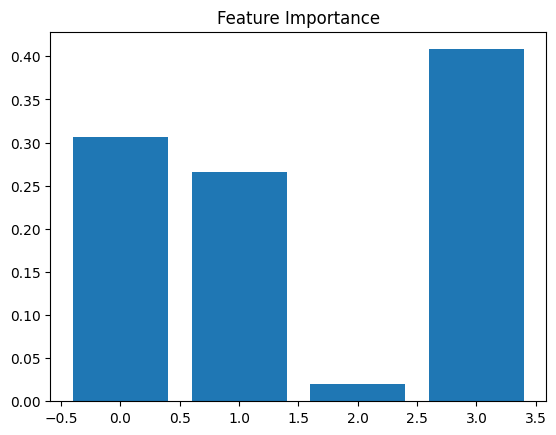


Sample Prediction: PASS


In [3]:
import polars as pl
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score
from xgboost import XGBClassifier

data = {
    "StudyHours": [2.5, 5.0, 5.5, 8.0, 1.0, 4.0, 6.0, 3.0, 7.5, 9.0],
    "Attendance": [70, 85, 60, 95, 50, 75, 80, 65, 90, 98],
    "Gender": ["M", "F", "F", "M", "M", "F", "M", "F", "F", "M"],
    "City": ["Delhi", "Mumbai", "Delhi", "Pune", "Mumbai", "Delhi", "Pune", "Mumbai", "Delhi", "Pune"],
    "Pass": [0, 1, 0, 1, 0, 1, 1, 0, 1, 1]
}
df = pl.DataFrame(data)

df = df.with_columns([
    (pl.col("StudyHours") + pl.col("Attendance")).alias("Engagement")
])

le = LabelEncoder()
df = df.with_columns(pl.Series("Gender", le.fit_transform(df["Gender"].to_numpy())))
df = df.to_dummies(columns=["City"])

y = df["Pass"].to_numpy()
X = df.drop("Pass").to_numpy()

selector = SelectKBest(score_func=f_classif, k=4)
X = selector.fit_transform(X, y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)

    results.append((name, acc))
    print(f"{name} → Acc:{acc:.2f} | Prec:{prec:.2f} | Recall:{rec:.2f}")

best_model_name = max(results, key=lambda x: x[1])
print("\nBest Model:", best_model_name)

grid = GridSearchCV(RandomForestClassifier(), {
    'n_estimators': [50, 100],
    'max_depth': [3, 5]
}, cv=2)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

joblib.dump(best_model, "model.pkl")

print("\nBest Params:", grid.best_params_)

plt.bar(range(len(best_model.feature_importances_)), best_model.feature_importances_)
plt.title("Feature Importance")
plt.show()

def predict_student(data):
    model = joblib.load("model.pkl")
    return "PASS" if model.predict(data)[0] == 1 else "FAIL"

print("\nSample Prediction:", predict_student(X_test[0:1]))